In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [11]:
bank = pd.read_csv('/home/aiden/projects/ML/banking/dataset/bank-additional-full.csv', sep=';')

In [12]:
cluster_nums = ["age", "campaign", "previous"]
cluster_cats = ["job", "marital", "education", "housing", "loan", "poutcome"]

cluster_prep = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), cluster_nums),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cluster_cats),
    ],
    remainder="drop",  # Safely excludes duration, y, month, and all macro indicators
)

X_encoded = cluster_prep.fit_transform(bank)

pca = PCA(n_components=0.85, random_state=42)
X_cluster = pca.fit_transform(X_encoded)

print(f"Features reduced from {X_encoded.shape[1]} dummies to {X_cluster.shape[1]} PCA components.")

Features reduced from 30 dummies to 9 PCA components.


k = 2 | Inertia = 154772.6 | Silhouette = 0.3496
k = 3 | Inertia = 130135.0 | Silhouette = 0.1992
k = 4 | Inertia = 108248.7 | Silhouette = 0.2097
k = 5 | Inertia = 98394.1 | Silhouette = 0.1812
k = 6 | Inertia = 91886.7 | Silhouette = 0.1873
k = 7 | Inertia = 86697.8 | Silhouette = 0.1866


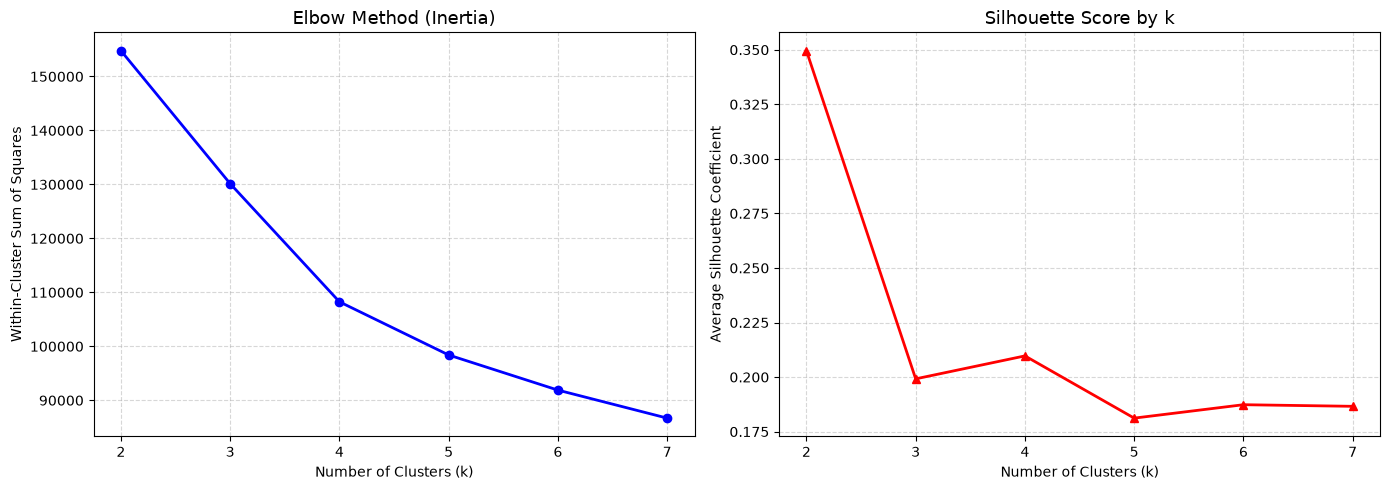

In [13]:
inertias = []
silhouette_scores = []
k_range = range(2, 8)

# Use a 5,000-sample subset for fast, reproducible silhouette calculation
sample_idx = np.random.RandomState(42).choice(
    X_cluster.shape[0], size=5000, replace=False
)
X_sub = X_cluster[sample_idx]

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_cluster)

    inertias.append(km.inertia_)
    score = silhouette_score(X_sub, labels[sample_idx])
    silhouette_scores.append(score)
    print(f"k = {k} | Inertia = {km.inertia_:.1f} | Silhouette = {score:.4f}")

# Plot side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertias, "bo-", linewidth=2)
ax1.set_title("Elbow Method (Inertia)", fontsize=13)
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Within-Cluster Sum of Squares")
ax1.grid(True, linestyle="--", alpha=0.5)

ax2.plot(k_range, silhouette_scores, "r^-", linewidth=2)
ax2.set_title("Silhouette Score by k", fontsize=13)
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Average Silhouette Coefficient")
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

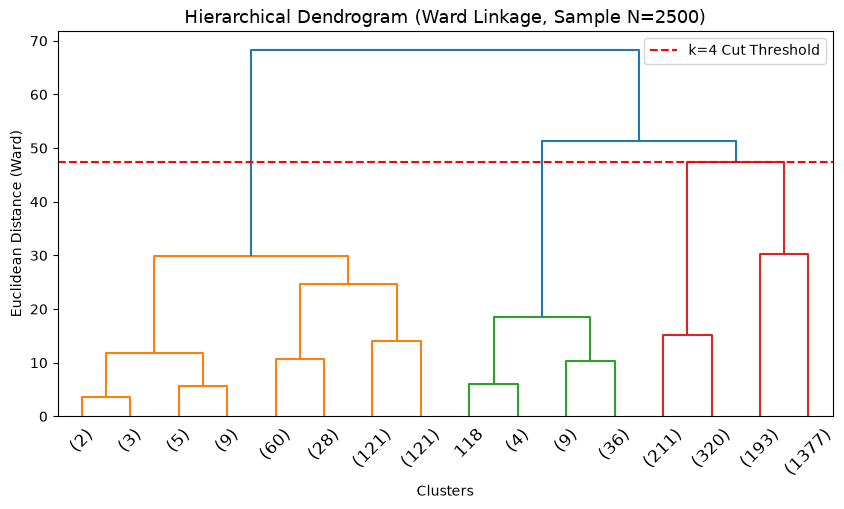

In [14]:
import scipy.cluster.hierarchy as sch

# Subsample 2,500 points (Ward linkage requires O(N^2) memory)
dendro_idx = np.random.RandomState(42).choice(
    X_cluster.shape[0], size=2500, replace=False
)
X_dendro = X_cluster[dendro_idx]

plt.figure(figsize=(10, 5))
plt.title("Hierarchical Dendrogram (Ward Linkage, Sample N=2500)", fontsize=13)
plt.xlabel("Clusters")
plt.ylabel("Euclidean Distance (Ward)")

linkage_matrix = sch.linkage(X_dendro, method="ward")
sch.dendrogram(linkage_matrix, truncate_mode="level", p=3, leaf_rotation=45)
plt.axhline(
    y=linkage_matrix[-3, 2],
    color="r",
    linestyle="--",
    label="k=4 Cut Threshold",
)
plt.legend()
plt.show()

In [15]:
best_k = 4
final_kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=42)

bank["Cluster"] = final_kmeans.fit_predict(X_cluster)
bank["subscribed"] = (bank["y"] == "yes").astype(int)

In [18]:
# 1. Numerical averages per cluster
cluster_profile = (
    bank.groupby("Cluster")
    .agg(
        Size=("age", "count"),
        Avg_Age=("age", "mean"),
        Avg_Calls=("campaign", "mean"),
        Avg_Previous=("previous", "mean")
        ,
        Conversion_Rate=("subscribed", "mean"),
    )
    .reset_index()
)

cluster_profile["% of Bank"] = (cluster_profile["Size"] / len(bank)) * 100

# 2. Most common categorical traits per cluster
modes = (
    bank.groupby("Cluster")[["job", "education", "housing", "loan", "poutcome"]]
    .agg(lambda s: s.mode().iloc[0])
    .reset_index()
)

# Merge into one clean summary table
summary_table = pd.merge(cluster_profile, modes, on="Cluster")
summary_table = summary_table.sort_values(by="Conversion_Rate", ascending=False)

print("=== Customer Personas & Conversion Profile ===")
display(
    summary_table.round(
        {
            "Avg_Age": 1,
            "Avg_Calls": 1,
            "Avg_Previous": 2,
            "Conversion_Rate": 3,
            "% of Bank": 1,
        }
    )
)

=== Customer Personas & Conversion Profile ===


,Cluster,Size,Avg_Age,Avg_Calls,Avg_Previous,Conversion_Rate,% of Bank,job,education,housing,loan,poutcome
1,1,5456,39.5,1.9,1.27,0.261,13.2,admin.,university.degree,yes,no,failure
3,3,20756,33.4,2.2,0.00,0.094,50.4,admin.,university.degree,yes,no,nonexistent
0,0,13294,50.7,2.2,0.01,0.090,32.3,blue-collar,university.degree,yes,no,nonexistent
2,2,1682,39.8,12.7,0.01,0.040,4.1,admin.,university.degree,yes,no,nonexistent
